#                                               🛍️ Customer Shopping Behavior Analysis

## 📌 Objective
The objective of this project is to analyze customer purchasing behavior to uncover key insights that can help businesses improve sales, customer targeting, and marketing strategies.

## 🧠 Key Business Questions
1. Which product categories generate the highest revenue?
2. Which customer segments spend the most?
3. Does discount application influence purchase behavior?
4. How does purchase frequency impact spending?
5. What patterns exist across age groups and gender?

# ➡️ Importing Libraries

In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.set_style("whitegrid")

<Figure size 800x500 with 0 Axes>

# ➡️ Loading Dataset

In [111]:
df = pd.read_csv("C:\\Users\\Abhinav Sharma\\OneDrive\\Desktop\\Retail Customer Behaviour Data Analyst project\\customer_shopping_behavior.csv")
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


# ➡️ Data Overview

In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [113]:
df.describe(include="all")

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3863.000000,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,675,2223,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.750065,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.716983,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


In [114]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [115]:
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ','_')
df = df.rename(columns={'purchase_amount_(usd)':'purchase_amount'})

In [116]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='object')

In [125]:
df.groupby('age_group')['purchase_amount'].describe()

C:\Users\Abhinav Sharma\AppData\Local\Temp\ipykernel_8812\2534468461.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_group')['purchase_amount'].describe()


,count,mean,std,min,25%,50%,75%,max
age_group,,,,,,,,
Teen,69.0,59.985507,23.823797,22.0,39.0,62.0,77.0,100.0
Young Adult,880.0,60.386364,23.750041,20.0,39.0,61.0,81.0,100.0
Adult,1093.0,59.402562,23.268399,20.0,39.0,59.0,80.0,100.0
Middle Age,1135.0,59.657269,23.883050,20.0,38.0,59.0,80.5,100.0
Senior,723.0,59.701245,23.956258,20.0,38.0,59.0,81.0,100.0


# ➡️ Data Cleaning

In [119]:
df['review_rating'] = df['review_rating'].fillna(df['review_rating'].mean())

# ➡️ Feature Engineering

In [120]:
# Age Group Segmentation
df['age_group'] = pd.cut(df['age'], 
                        bins=[0,18,30,45,60,100], 
                        labels=['Teen','Young Adult','Adult','Middle Age','Senior'])

# Convert purchase frequency to numeric
freq_map = {'Low':1, 'Medium':2, 'High':3}
df['frequency_of_purchases'] = df['frequency_of_purchases'].map(freq_map)

In [121]:
df[['age', 'age_group']].head(10)

,age,age_group
0,55,Middle Age
1,19,Young Adult
2,50,Middle Age
3,21,Young Adult
4,45,Adult
5,46,Middle Age
6,63,Senior
7,27,Young Adult
8,26,Young Adult
9,57,Middle Age


In [122]:
df.groupby('category')['purchase_amount'].sum().sort_values(ascending=False)

category
Clothing       104264
Accessories     74200
Footwear        36093
Outerwear       18524
Name: purchase_amount, dtype: int64

## 📈 Category VS Revenue

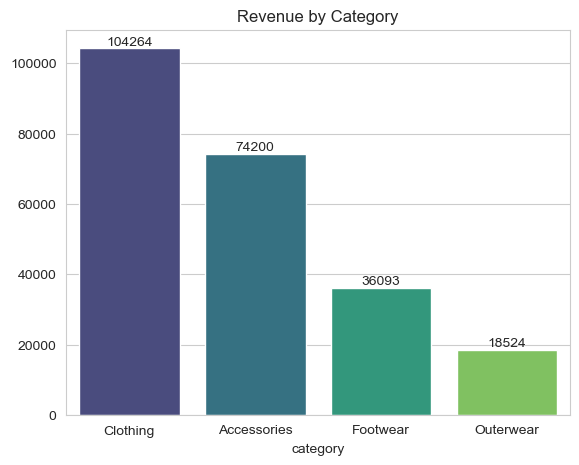

In [123]:
category_rev = df.groupby('category')['purchase_amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(6.5,5))

ax = sns.barplot(
    x=category_rev.index, 
    y=category_rev.values, 
    hue=category_rev.index,   
    palette="viridis",
    legend=False              
)

plt.title("Revenue by Category")
plt.xticks(rotation=0)

for i in ax.containers:
    ax.bar_label(i)

plt.show()

## 💡 Insight:
Clothing emerges as the top-performing category, followed by Accessories, indicating that customers show a strong preference towards fashion-related products. This suggests that investing more in these categories through targeted marketing, better inventory management, and promotional strategies could significantly boost overall revenue.

C:\Users\Abhinav Sharma\AppData\Local\Temp\ipykernel_8812\3776213997.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_spending = df.groupby('age_group')['purchase_amount'].mean()


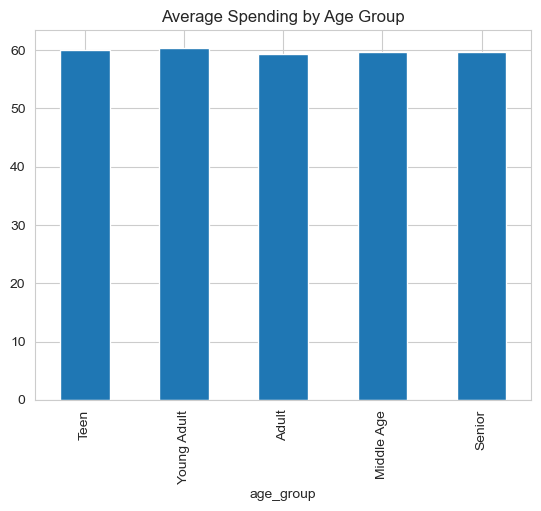

In [124]:
age_spending = df.groupby('age_group')['purchase_amount'].mean()

age_spending.plot(kind='bar')
plt.title("Average Spending by Age Group")
plt.show()

### 💡 Insight:
There is minimal variation in average spending across age groups, suggesting that purchasing behavior is consistent regardless of age. This indicates that demographic segmentation based on age may not be as effective as behavioral segmentation for targeting customers.

# ➡️ Gender-Based Analysis

In [130]:
gender_spending = df.groupby('gender')['purchase_amount'].mean()
print(gender_spending)

gender
Female    60.249199
Male      59.536199
Name: purchase_amount, dtype: float64


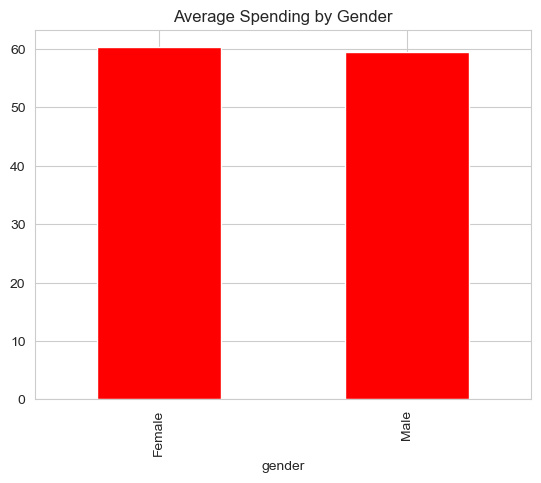

In [140]:
gender_spending = df.groupby('gender')['purchase_amount'].mean()

gender_spending.plot(kind='bar', color = 'red')
plt.title("Average Spending by Gender")
plt.show()

## 💡 Insight:
There is minimal variation in average spending across genders, suggesting that purchasing behavior is consistent regardless of gender. This indicates that gender-based segmentation may not be highly effective for targeting high-spending customers.

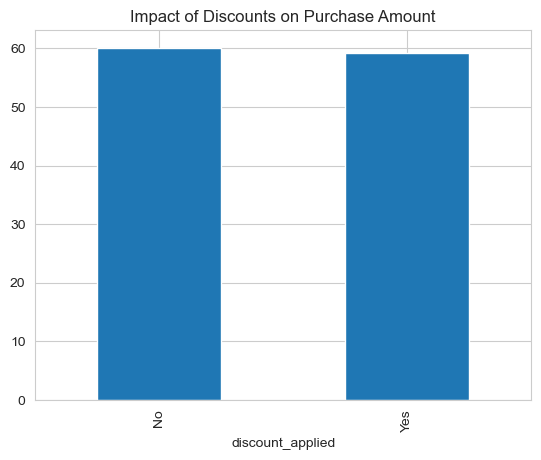

In [141]:
discount_impact = df.groupby('discount_applied')['purchase_amount'].mean()

discount_impact.plot(kind='bar')
plt.title("Impact of Discounts on Purchase Amount")
plt.show()

# Conclusion 📊

# Analysis of the sales data provides the following key insights:

✔️Top Categories
Clothing emerged as the leading contributor to total sales, closely followed by Accessories. These two categories together form the majority of revenue, indicating strong customer preference.

✔️Gender-wise Trends
Sales distribution between male and female customers is fairly balanced, with no extreme disparity. This suggests marketing and inventory strategies can cater to both genders effectively.

✔️Age Group Insights
While different age groups were analyzed, the average sales across age segments are largely similar, meaning no particular age group dominates purchases. Targeted promotions can still be designed for minor variations but broadly all age groups contribute equally.

✔️Purchase Frequency
Most customers make 1–2 purchases per month, reflecting consistent but moderate engagement. There are no extreme outliers, so strategies focused on encouraging repeat purchases could further boost overall sales.

✔️Actionable Recommendations
Prioritize stock and promotions for Clothing and Accessories.
Maintain balanced marketing across male and female segments.
Consider loyalty programs or offers to slightly increase purchase frequency without overcomplicating inventory management.